In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [31]:
# Load the Online Retail dataset
df = pd.read_csv("data/time_series_data.csv") 

print(df.head())
print(df.describe())

   t  ProductP1  ProductP2  ProductP3  ProductP4  ProductP5  price  \
0  1        197         66        266        113          2      1   
1  2        153         44        264         74          1      2   
2  3        128         55        317        116          0      1   
3  4        133         57        390         70          0      2   
4  5        120         47        440        141          1      1   

   temperature  
0           18  
1           21  
2           19  
3           17  
4           18  
                t   ProductP1   ProductP2  ProductP3   ProductP4   ProductP5  \
count  100.000000  100.000000  100.000000   100.0000  100.000000  100.000000   
mean    50.500000  148.370000  153.440000   631.5800   80.120000    0.550000   
std     29.011492   18.061989   68.164288   202.8871   36.780891    1.225775   
min      1.000000  107.000000   42.000000   203.0000   11.000000    0.000000   
25%     25.750000  134.000000   95.500000   491.7500   55.750000    0.000000 

In [41]:
# Checking for missing values and duplicate rows
print("Missing Values:\n", df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())


Missing Values:
 t              0
ProductP1      0
ProductP2      0
ProductP3      0
ProductP4      0
ProductP5      0
price          0
temperature    0
dtype: int64
Duplicate Rows: 0


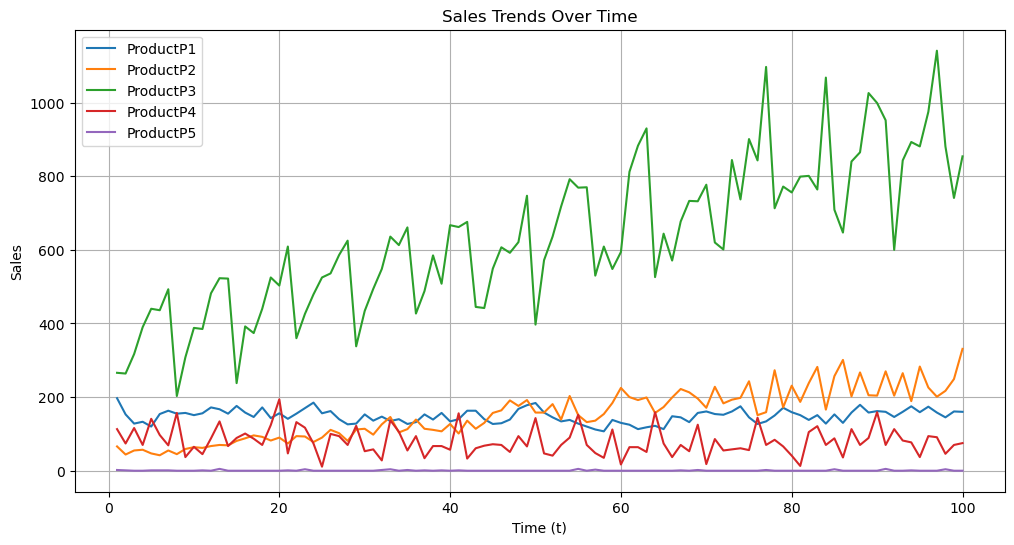

In [43]:
# Plot sales trends over time for each product
plt.figure(figsize=(12, 6))
for product in ['ProductP1', 'ProductP2', 'ProductP3', 'ProductP4', 'ProductP5']:
    plt.plot(df['t'], df[product], label=product)
plt.xlabel('Time (t)')
plt.ylabel('Sales')
plt.title('Sales Trends Over Time')
plt.legend()
plt.grid(True)
plt.show()

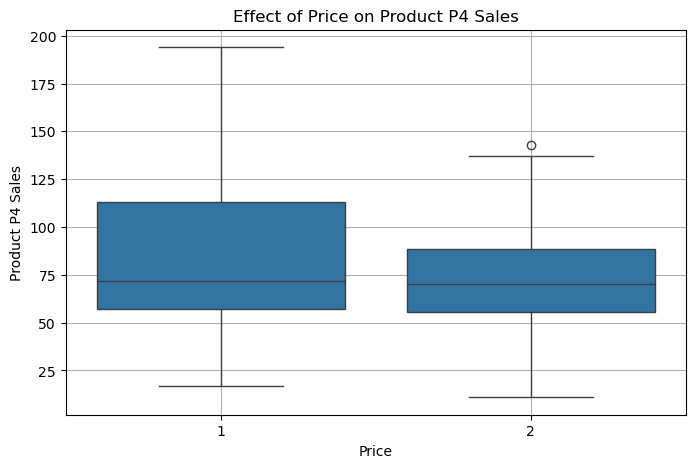

In [45]:
# Effect of Price on Product P4 Sales
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['price'], y=df['ProductP4'])
plt.xlabel('Price')
plt.ylabel('Product P4 Sales')
plt.title('Effect of Price on Product P4 Sales')
plt.grid(True)
plt.show()

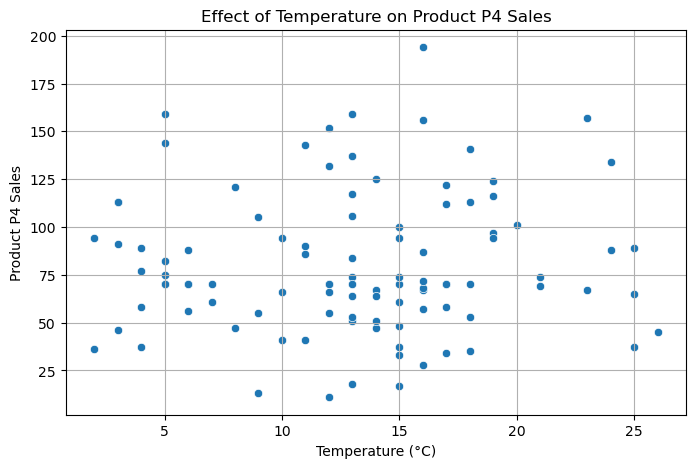

In [47]:
# Effect of Temperature on Product P4 Sales
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['temperature'], y=df['ProductP4'])
plt.xlabel('Temperature (°C)')
plt.ylabel('Product P4 Sales')
plt.title('Effect of Temperature on Product P4 Sales')
plt.grid(True)
plt.show()

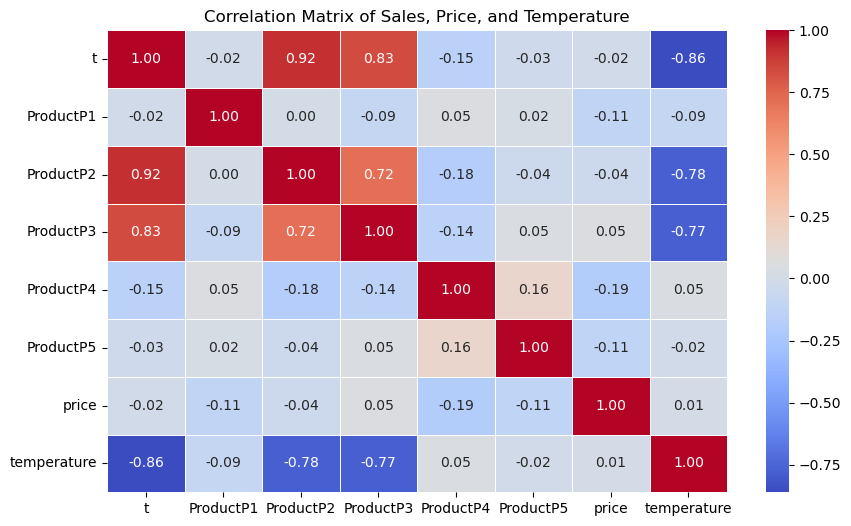

In [49]:
# Compute correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Sales, Price, and Temperature")
plt.show()

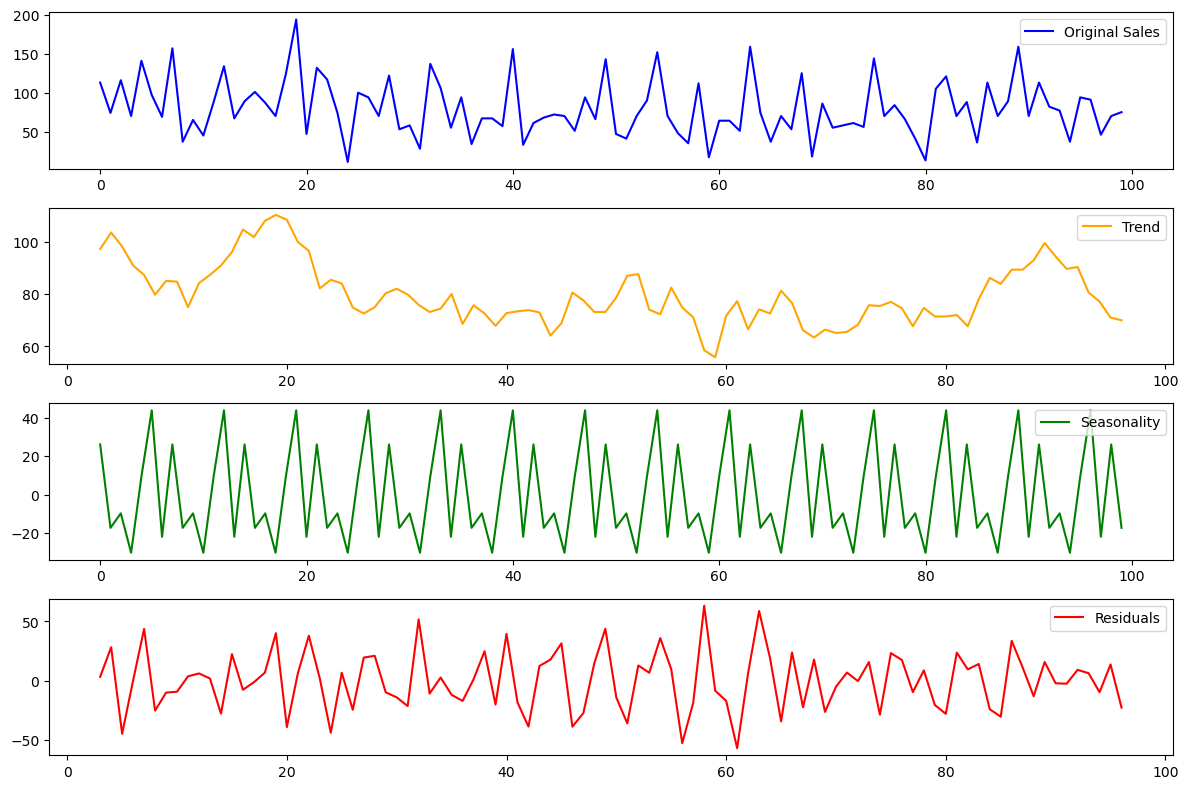

In [51]:
# Perform time-series decomposition for Product P4
decomposition = seasonal_decompose(df['ProductP4'], period=7, model='additive')
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df['ProductP4'], label='Original Sales', color='blue')
plt.legend()
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend()
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.legend()
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.legend()
plt.tight_layout()
plt.show()

#### # SARIMA Model for Forecasting Product P4 Sales
sarima_model = SARIMAX(df['ProductP4'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), 
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_result = sarima_model.fit()

# Forecast the next 14 days
forecast_steps = 14
forecast_index = range(len(df), len(df) + forecast_steps)
forecast = sarima_result.forecast(steps=forecast_steps)

# Plot actual vs. forecasted sales
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['ProductP4'], label="Actual Sales", color='blue')
plt.plot(forecast_index, forecast, label="Forecasted Sales", color='red', linestyle="dashed")
plt.xlabel("Time (t)")
plt.ylabel("Product P4 Sales")
plt.title("Product P4 Sales Forecast for the Next 14 Days")
plt.legend()
plt.grid(True)
plt.show()